In [ ]:
"""
Модель Hovorka.

"""

import numpy as np
from scipy.integrate import odeint
from scipy.integrate import ode
from scipy.optimize import fsolve
import pandas as pd


def hovorka_parameters(BW):
    """Функция, возвращающая параметры модели Ховорки для заданного веса тела"""
    V_I = 0.12*BW              # Объем распределения инсулина [L]
    V_G = 0.16*BW              # Объем распределения глюкозы [L]
    F_01 = 0.0097*BW           # Неконтролируемый поток глюкозы [mmol/min]
    EGP_0 = 0.0161*BW          # Производство глюкозы печенью при нулевой концентрации инсулина [mmol/min]

    # Независимые от пациента параметры
    S_IT = 51.2e-4             # Чувствительность инсулина при транспортировке [L/min*mU]
    S_ID = 8.2e-4              # Чувствительность инсулина при утилизации [L/min*mU]
    S_IE = 520e-4              # Чувствительность инсулина при производстве глюкозы [L/mU]

    tau_G = 40                 # Время до максимального поглощения углеводов [мин]
    tau_I = 55                 # Время до максимального поглощения инсулина [мин]

    A_G = 0.8                  # Биодоступность углеводов [1]
    k_12 = 0.066               # Скорость переноса [мин^-1]

    k_a1 = 0.006               # Скорость деактивации инсулина при транспортировке [мин^-1]
    k_b1 = S_IT * k_a1         # Скорость активации инсулина при транспортировке
    k_a2 = 0.06                # Скорость деактивации инсулина при утилизации [мин^-1]
    k_b2 = S_ID * k_a2         # Скорость активации инсулина при утилизации
    k_a3 = 0.03                # Скорость деактивации инсулина при производстве глюкозы [мин^-1]
    k_b3 = S_IE * k_a3         # Скорость активации инсулина при производстве глюкозы

    k_e = 0.138                # Элиминация инсулина из плазмы [мин^-1]

    # Возвращаем все параметры в виде списка
    return [tau_G, tau_I, A_G, k_12, k_a1, k_b1, k_a2, k_b2, k_a3, k_b3, k_e, V_I, V_G, F_01, EGP_0]

def hovorka_model(t, x, u, D, P): #####x t
    """Модель Ховорки для решения ОДУ"""
    #print("Input x:", len(x))  # Отладочный вывод

    D1, D2, S1, S2, Q1, Q2, I, x1, x2, x3, C = x

    tau_G, tau_I, A_G, k_12, k_a1, k_b1, k_a2, k_b2, k_a3, k_b3, k_e, V_I, V_G, F_01, EGP_0 = P

    U_G = D2/tau_G             # Скорость поглощения глюкозы [mmol/min]
    U_I = S2/tau_I             # Скорость поглощения инсулина [mU/min]

    G = Q1/V_G                 # Концентрация глюкозы [mmol/L]

    if G >= 4.5:
        F_01c = F_01           # Потребление глюкозы ЦНС [mmol/min]
    else:
        F_01c = F_01 * G / 4.5

    if G >= 9:
        F_R = 0.003 * (G - 9) * V_G  # Почечная экскреция глюкозы [mmol/min]
    else:
        F_R = 0
        
    # Mass balances/differential equations
    xdot = np.zeros (11);

    xdot[ 0 ] = A_G*D-D1/tau_G                                # dD1
    xdot[ 1 ] = D1/tau_G-U_G                                  # dD2
   
    xdot[ 2 ] = u-S1/tau_I                                    # dS1
    xdot[ 3 ] = S1/tau_I-U_I                                  # dS2
   
    xdot[ 4 ] = -(F_01c+F_R) - x1*Q1 + k_12*Q2 + U_G + max(EGP_0*(1-x3), 0)   # dQ1
    xdot[ 5 ] = x1*Q1-(k_12+x2)*Q2                            # dQ2

    xdot[ 6 ] = U_I/V_I-k_e*I                                 # dI
    
    xdot[ 7 ] = k_b1*I-k_a1*x1                                # dx1
    xdot[ 8 ] = k_b2*I-k_a2*x2                                # dx2
    xdot[ 9 ] = k_b3*I-k_a3*x3                                # dx3

    # ===============
    # CGM delay
    # ===============
    ka_int = 0.073

    xdot[10] = ka_int*(G - C)

    return xdot

def hovorka_model_tuple(x, *pars):
    u, D, P = pars
    t = 0
    return hovorka_model(t, x, u, D, P)


def simulate_glucose_concentrationHOVITER(total_time, BW, meals, meal_indicator, basal, forecast_steps=10): 
    P = hovorka_parameters(BW)  
    initial_pars = (basal, 0, P)
    x0 = fsolve(hovorka_model_tuple, np.zeros(11), args=initial_pars)
    print("init bg ", x0[-1] * 18)

    BG = [x0[-1] * 18]
    hov_horizon = []
    
    X = ode(hovorka_model)
    X.set_integrator('dopri5')
    X.set_initial_value(x0, 0).set_f_params(0, 0, P)

    while X.successful() and X.t < total_time - 1:  
        insulin_rate = meal_indicator[int(X.t)]
        X.set_f_params(insulin_rate, meals[int(X.t)], P)
        solver = X.integrate(X.t + 1)
        BG.append(solver[-1] * 18)

        current_state = X.y.copy()
        current_time = X.t

        temp_BG = []
        cho = 0
        ins = insulin_rate if int(X.t) == 0 else min(meal_indicator[int(X.t)], meal_indicator[int(X.t - 1)])
        
        add_data = pd.DataFrame({
            'CHO': [cho] * forecast_steps,
            'insulin': [ins] * forecast_steps
        })
        
        for j in range(forecast_steps):
            X.set_f_params(add_data['insulin'].iloc[j], add_data['CHO'].iloc[j], P)
            if not X.successful():
                break
            temp_state = X.integrate(X.t + 1)
            temp_BG.append(temp_state[-1] * 18)
        
        hov_horizon.append(temp_BG[-1])
        X.set_initial_value(current_state, current_time)
        print(X.successful(), " ", int(X.t))
        
    return BG, hov_horizon





In [ ]:
import matplotlib.pyplot as plt

def graph_output(total_time, glucose_levels_hov):
    time_points = np.arange(0, total_time)
    plt.figure(figsize=(12, 6))
    print("SS", glucose_levels_hov[500])
    plt.plot(time_points, glucose_levels_hov[:len(time_points)], label='Glucose HOVORKA (mg/dL)', color='blue')
    plt.title('Сравнение уровня глюкозы по двум моделям')
    plt.xlabel('Время (минуты)')
    plt.ylabel('Уровень глюкозы (mg/dL)')
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
data = pd.read_csv('datatest_hov1.csv')
CHO = data['CHO']
INS = data['INS']
BG = data['BG']

BW = 70 #kg 
basal_hov = 5.95

horizons = [30, 60]
for horizon in horizons:
    glucose_levels_hov, hov_horizon= simulate_glucose_concentrationHOVITER(len(data), BW, CHO, INS, basal_hov, horizon)

    graph_output(len(glucose_levels_hov), glucose_levels_hov)
    df_hov_horizon = pd.DataFrame({
        'BG_hov': hov_horizon
    })
    graph_output(len(hov_horizon), hov_horizon)

    df_hov_horizon.to_csv(f'hov_horizon{horizon}_adolescent#001.csv', index=False)


SS 86.9144206979672


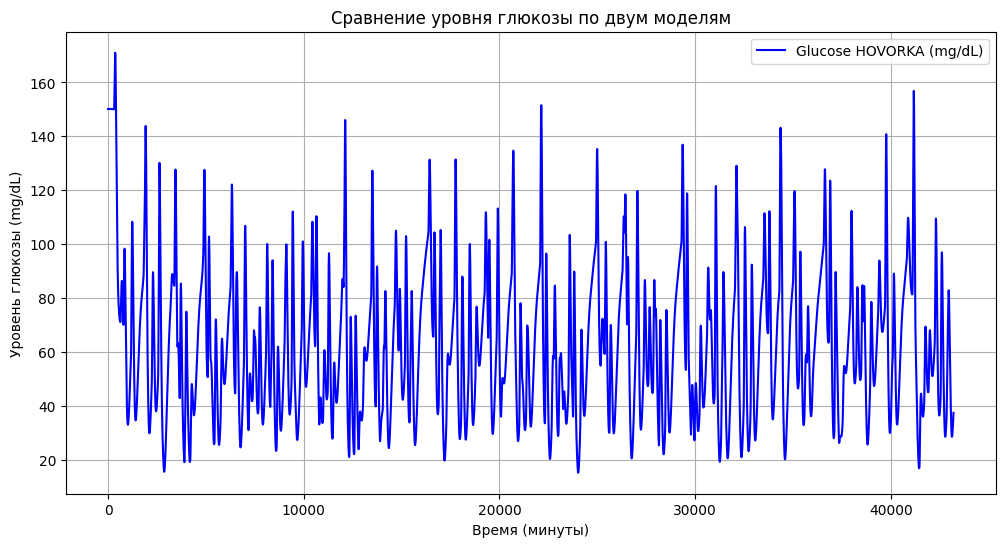

SS 82.08861832011192


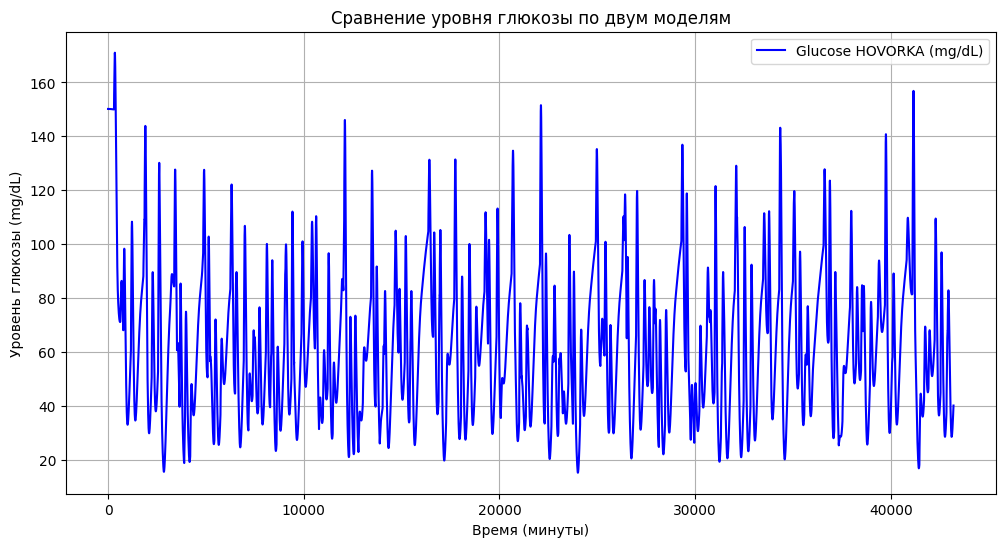